In [1]:
import pandas as pd

file_path = r"C:\Users\user\Desktop\기업 연계 데이터\original data\Membership.csv"

df = pd.read_csv(file_path)

unique_product_cd_count = df["product_cd"].nunique()
unique_billing_method_count = df["billing_method"].nunique()

print("고유한 product_cd 개수:", unique_product_cd_count)
print("고유한 billing_method 개수:", unique_billing_method_count)



고유한 product_cd 개수: 53
고유한 billing_method 개수: 10


In [2]:
# is_user_verified가 Y인 데이터만 필터링
verified_df = df[df["is_user_verified"] == "Y"]

# gender 분포 확인
gender_counts = verified_df["gender"].value_counts(dropna=False)
gender_ratio = verified_df["gender"].value_counts(normalize=True, dropna=False) * 100

print("성별 개수 분포")
print(gender_counts)

print("\n성별 비율 분포(%)")
print(gender_ratio.round(2))


성별 개수 분포
gender
F    8369
M    5071
N      47
Name: count, dtype: int64

성별 비율 분포(%)
gender
F    62.05
M    37.60
N     0.35
Name: proportion, dtype: float64


In [3]:
# age 값별 개수 집계, 결측치 포함
age_counts = df["age"].value_counts(dropna=False).sort_index()

print(age_counts)


age
0.0         5
5.0         1
15.0      324
20.0     2464
25.0     3075
30.0     2721
35.0     1785
40.0     5104
45.0      967
50.0      719
55.0      375
60.0      238
65.0      133
70.0       57
75.0       20
80.0       16
85.0        9
90.0        4
120.0       1
950.0       1
NaN       164
Name: count, dtype: int64


## Single

### Age

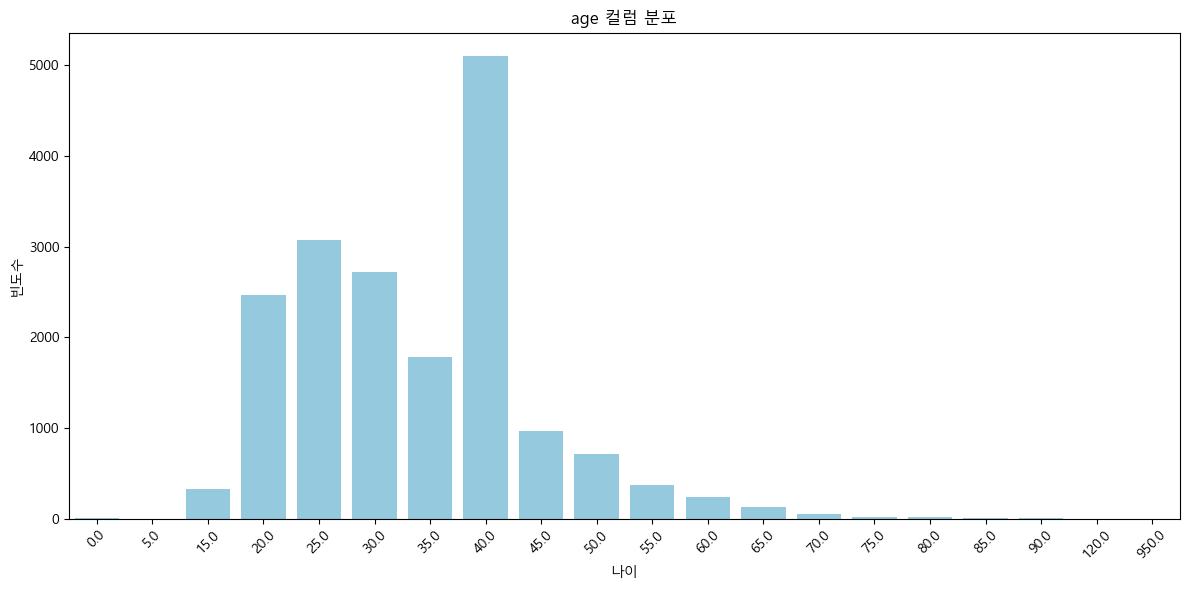

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# age 컬럼 수치형 변환
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# 결측치 제거 후 나이별 빈도수 계산
age_count = df["age"].dropna().value_counts().sort_index()

# 한글 출력 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 그래프 크기 설정
plt.figure(figsize=(12, 6))

# 막대그래프 생성
sns.barplot(x=age_count.index, y=age_count.values, color="skyblue")

# 그래프 제목 및 축 이름 설정
plt.title("age 컬럼 분포")
plt.xlabel("나이")
plt.ylabel("빈도수")

# x축 눈금 회전
plt.xticks(rotation=45)

# 레이아웃 조정
plt.tight_layout()

# 그래프 출력
plt.show()


IQR

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# age 컬럼 수치형 변환
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# 한글 출력 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 확인할 수치형 컬럼 선택
numeric_cols = ["age"]

# 이상치 요약 결과 저장용
outlier_result = []

for col in numeric_cols:
    valid_data = df[col].dropna()

    q1 = valid_data.quantile(0.25)
    q3 = valid_data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (valid_data < lower_bound) | (valid_data > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_ratio = round((outlier_count / len(valid_data)) * 100, 2)

    outlier_result.append({
        "컬럼명": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "하한값": lower_bound,
        "상한값": upper_bound,
        "이상치 수": outlier_count,
        "이상치 비율(%)": outlier_ratio,
        "최솟값": valid_data.min(),
        "최댓값": valid_data.max()
    })

# 결과 테이블
outlier_summary = pd.DataFrame(outlier_result)
display(outlier_summary)


,컬럼명,Q1,Q3,IQR,하한값,상한값,이상치 수,이상치 비율(%),최솟값,최댓값
0,age,25.0,40.0,15.0,2.5,62.5,246,1.37,0.0,950.0


In [6]:
# age 컬럼 수치형 변환
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# 10 이상 100 이하인 age만 사용
filtered_df = df[(df["age"] >= 10) ]

# 확인할 수치형 컬럼 선택
numeric_cols = ["age"]

# 결과 저장용
iqr_result = []

for col in numeric_cols:
    valid_data = filtered_df[col].dropna()

    q1 = valid_data.quantile(0.25)
    q3 = valid_data.quantile(0.75)
    iqr = q3 - q1

    # 실제 값 기준 하한값 계산
    lower_bound = q1 - (1.5 * iqr)

    # 실제 값 기준 상한값 계산
    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (valid_data < lower_bound) | (valid_data > upper_bound)

    outlier_count = outlier_mask.sum()
    outlier_ratio = round((outlier_count / len(valid_data)) * 100, 2)

    iqr_result.append({
        "컬럼명": col,
        "사용 조건": "10 이상",
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "IQR 기준값": "Q1 - 1.5*IQR ~ Q3 + 1.5*IQR",
        "실제 하한값(age)": round(lower_bound, 2),
        "실제 상한값(age)": round(upper_bound, 2),
        "이상치 수": outlier_count,
        "이상치 비율(%)": outlier_ratio,
        "최솟값": valid_data.min(),
        "최댓값": valid_data.max(),
        "분석 데이터 수": len(valid_data)
    })

iqr_summary = pd.DataFrame(iqr_result)
display(iqr_summary)


,컬럼명,사용 조건,Q1,Q3,IQR,IQR 기준값,실제 하한값(age),실제 상한값(age),이상치 수,이상치 비율(%),최솟값,최댓값,분석 데이터 수
0,age,10 이상,25.0,40.0,15.0,Q1 - 1.5*IQR ~ Q3 + 1.5*IQR,2.5,62.5,241,1.34,15.0,950.0,18013


Z-SCORE

In [7]:
# Z-score 기준값 설정
threshold = 3

# age 컬럼 수치형 변환
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# 확인할 수치형 컬럼 선택
numeric_cols = ["age"]

# 결과 저장용
zscore_result = []

for col in numeric_cols:
    valid_data = df[col].dropna()

    mean_value = valid_data.mean()
    std_value = valid_data.std()

    # 실제 값 기준 하한값, 상한값 계산
    lower_bound = mean_value - (threshold * std_value)
    upper_bound = mean_value + (threshold * std_value)

    z_scores = (valid_data - mean_value) / std_value
    outlier_mask = z_scores.abs() > threshold

    outlier_count = outlier_mask.sum()
    outlier_ratio = round((outlier_count / len(valid_data)) * 100, 2)

    zscore_result.append({
        "컬럼명": col,
        "평균": round(mean_value, 2),
        "표준편차": round(std_value, 2),
        "z-score 기준값": f"|z| > {threshold}",
        "실제 하한값(age)": round(lower_bound, 2),
        "실제 상한값(age)": round(upper_bound, 2),
        "이상치 수": outlier_count,
        "이상치 비율(%)": outlier_ratio,
        "최솟값": valid_data.min(),
        "최댓값": valid_data.max()
    })

zscore_summary = pd.DataFrame(zscore_result)
display(zscore_summary)


,컬럼명,평균,표준편차,z-score 기준값,실제 하한값(age),실제 상한값(age),이상치 수,이상치 비율(%),최솟값,최댓값
0,age,33.92,12.61,|z| > 3,-3.9,71.74,51,0.28,0.0,950.0


In [8]:
# Z-score 기준값 설정
threshold = 3

# age 컬럼 수치형 변환
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# 10 이상인 age만 사용
filtered_df = df[df["age"] >= 10]

# 확인할 수치형 컬럼 선택
numeric_cols = ["age"]

# 결과 저장용
zscore_result = []

for col in numeric_cols:
    valid_data = filtered_df[col].dropna()

    mean_value = valid_data.mean()
    std_value = valid_data.std()

    # 실제 하한값 계산
    lower_bound = mean_value - (threshold * std_value)

    # 실제 상한값 계산
    upper_bound = mean_value + (threshold * std_value)

    z_scores = (valid_data - mean_value) / std_value
    outlier_mask = z_scores.abs() > threshold

    outlier_count = outlier_mask.sum()
    outlier_ratio = round((outlier_count / len(valid_data)) * 100, 2)

    zscore_result.append({
        "변수": col,
        "분석 조건": "10 이상",
        "평균": round(mean_value, 2),
        "표준편차": round(std_value, 2),
        "이상치 기준": f"|z| > {threshold}",
        "하한값": round(lower_bound, 2),
        "상한값": round(upper_bound, 2),
        "최소값": valid_data.min(),
        "최대값": valid_data.max(),
        "이상치 수": outlier_count,
        "이상치 비율": f"{outlier_ratio}%",
        "데이터 수": len(valid_data)
    })

zscore_summary = pd.DataFrame(zscore_result)

# 세로형 표로 변환
zscore_summary_vertical = zscore_summary.set_index("변수").T

display(zscore_summary_vertical)


변수,age
분석 조건,10 이상
평균,33.93
표준편차,12.59
이상치 기준,|z| > 3
하한값,-3.85
상한값,71.72
최소값,15.0
최대값,950.0
이상치 수,51
이상치 비율,0.28%


### age
 >10 미만은 제거하고 그 후 이상치 제거 

In [9]:
import pandas as pd

# Z-score 기준값 설정
threshold = 3

# age 컬럼 수치형 변환
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# age가 10 이상인 데이터만 사용
df_age_10 = df[df["age"] >= 10].copy()

# 평균, 표준편차 계산
mean_value = df_age_10["age"].mean()
std_value = df_age_10["age"].std()

# 실제 값 기준 하한값, 상한값 계산
lower_bound = mean_value - (threshold * std_value)
upper_bound = mean_value + (threshold * std_value)

# 이상치 제거 데이터프레임 생성
df_age_cleaned = df_age_10[
    (df_age_10["age"] >= lower_bound) & (df_age_10["age"] <= upper_bound)
].copy()

# 결과 확인
print("원래 데이터 수:", len(df))
print("10 미만 제거 후 데이터 수:", len(df_age_10))
print("이상치 제거 후 데이터 수:", len(df_age_cleaned))
print("제거된 이상치 수:", len(df_age_10) - len(df_age_cleaned))
print("실제 하한값(age):", round(lower_bound, 2))
print("실제 상한값(age):", round(upper_bound, 2))


원래 데이터 수: 18183
10 미만 제거 후 데이터 수: 18013
이상치 제거 후 데이터 수: 17962
제거된 이상치 수: 51
실제 하한값(age): -3.85
실제 상한값(age): 71.72


### Amount

(1) IQR

In [10]:
# amount 컬럼 수치형 변환
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

# 100보다 작은 amount만 사용
filtered_df = df[df["amount"] < 100]

# 확인할 수치형 컬럼 선택
numeric_cols = ["amount"]

# 결과 저장용
iqr_result = []

for col in numeric_cols:
    valid_data = filtered_df[col].dropna()

    q1 = valid_data.quantile(0.25)
    q3 = valid_data.quantile(0.75)
    iqr = q3 - q1

    # 실제 값 기준 하한값 계산
    lower_bound = q1 - (1.5 * iqr)

    # 실제 값 기준 상한값 계산
    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (valid_data < lower_bound) | (valid_data > upper_bound)

    outlier_count = outlier_mask.sum()
    outlier_ratio = round((outlier_count / len(valid_data)) * 100, 2)

    iqr_result.append({
        "컬럼명": col,
        "사용 조건": "100 미만",
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "IQR 기준값": "Q1 - 1.5*IQR ~ Q3 + 1.5*IQR",
        "실제 하한값(amount)": round(lower_bound, 2),
        "실제 상한값(amount)": round(upper_bound, 2),
        "이상치 수": outlier_count,
        "이상치 비율(%)": outlier_ratio,
        "최솟값": valid_data.min(),
        "최댓값": valid_data.max(),
        "분석 데이터 수": len(valid_data)
    })

iqr_summary = pd.DataFrame(iqr_result)
display(iqr_summary)


,컬럼명,사용 조건,Q1,Q3,IQR,IQR 기준값,실제 하한값(amount),실제 상한값(amount),이상치 수,이상치 비율(%),최솟값,최댓값,분석 데이터 수
0,amount,100 미만,9.99,13.49,3.5,Q1 - 1.5*IQR ~ Q3 + 1.5*IQR,4.74,18.74,7,0.23,7.69,29.69,3094


(2) Z-score

In [11]:
# Z-score 기준값 설정
threshold = 3

# amount 컬럼 수치형 변환
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")

# 100보다 작은 amount만 사용
filtered_df = df[df["amount"] < 100]

# 확인할 수치형 컬럼 선택
numeric_cols = ["amount"]

# 결과 저장용
zscore_result = []

for col in numeric_cols:
    valid_data = filtered_df[col].dropna()

    mean_value = valid_data.mean()
    std_value = valid_data.std()

    # 실제 값 기준 하한값 계산
    lower_bound = mean_value - (threshold * std_value)

    # 실제 값 기준 상한값 계산
    upper_bound = mean_value + (threshold * std_value)

    z_scores = (valid_data - mean_value) / std_value
    outlier_mask = z_scores.abs() > threshold

    outlier_count = outlier_mask.sum()
    outlier_ratio = round((outlier_count / len(valid_data)) * 100, 2)

    zscore_result.append({
        "컬럼명": col,
        "사용 조건": "100 미만",
        "평균": round(mean_value, 2),
        "표준편차": round(std_value, 2),
        "z-score 기준값": f"|z| > {threshold}",
        "실제 하한값(amount)": round(lower_bound, 2),
        "실제 상한값(amount)": round(upper_bound, 2),
        "이상치 수": outlier_count,
        "이상치 비율(%)": outlier_ratio,
        "최솟값": valid_data.min(),
        "최댓값": valid_data.max(),
        "분석 데이터 수": len(valid_data)
    })

zscore_summary = pd.DataFrame(zscore_result)
display(zscore_summary)


,컬럼명,사용 조건,평균,표준편차,z-score 기준값,실제 하한값(amount),실제 상한값(amount),이상치 수,이상치 비율(%),최솟값,최댓값,분석 데이터 수
0,amount,100 미만,11.25,2.14,|z| > 3,4.82,17.67,7,0.23,7.69,29.69,3094


### amount
 >age에 대해서 10미만 제거 + 이상치 제거한 것에 대해서 amount 달러 이상치 처리 

In [12]:
import pandas as pd

# Z-score 기준값 설정
threshold = 3

# amount 컬럼 수치형 변환
df_age_cleaned["amount"] = pd.to_numeric(df_age_cleaned["amount"], errors="coerce")

# amount가 100 미만인 데이터만 추출
amount_under_100 = df_age_cleaned[df_age_cleaned["amount"] < 100].copy()

# 결측치 제거 데이터 생성
valid_data = amount_under_100["amount"].dropna()

# 평균, 표준편차 계산
mean_value = valid_data.mean()
std_value = valid_data.std()

# 실제 값 기준 하한값, 상한값 계산
lower_bound = mean_value - (threshold * std_value)
upper_bound = mean_value + (threshold * std_value)

# 원본 df_age_cleaned 기준 이상치 마스크 생성
outlier_mask = (
    (df_age_cleaned["amount"] < 100) &
    (
        (df_age_cleaned["amount"] < lower_bound) |
        (df_age_cleaned["amount"] > upper_bound)
    )
)

# 이상치 제거 데이터프레임 생성
df_age_amount_cleaned = df_age_cleaned[~outlier_mask].copy()

# 결과 확인
print("amount 100 미만 데이터 수:", len(amount_under_100))
print("평균:", round(mean_value, 2))
print("표준편차:", round(std_value, 2))
print("실제 하한값(amount):", round(lower_bound, 2))
print("실제 상한값(amount):", round(upper_bound, 2))
print("제거된 이상치 수:", outlier_mask.sum())
print("이상치 제거 후 데이터 수:", len(df_age_amount_cleaned))


amount 100 미만 데이터 수: 3058
평균: 11.25
표준편차: 2.15
실제 하한값(amount): 4.81
실제 상한값(amount): 17.69
제거된 이상치 수: 7
이상치 제거 후 데이터 수: 17955


### concurrent_streams
 >10세 미만, 이상치 제거 age + 달러 이상치 처리 amount + 이상치 처리 conc_streams

In [13]:
import pandas as pd

# concurrent_streams 컬럼 수치형 변환
df_age_amount_cleaned["concurrent_streams"] = pd.to_numeric(
    df_age_amount_cleaned["concurrent_streams"],
    errors="coerce"
)

# concurrent_streams가 1, 2, 4인 행만 선택
df_age_amount_streams_cleaned = df_age_amount_cleaned[
    df_age_amount_cleaned["concurrent_streams"].isin([1, 2, 4])
].copy()

# 결과 확인
print("변환 전 데이터 수:", len(df_age_amount_cleaned))
print("필터링 후 데이터 수:", len(df_age_amount_streams_cleaned))
print("제외된 행 수:", len(df_age_amount_cleaned) - len(df_age_amount_streams_cleaned))


변환 전 데이터 수: 17955
필터링 후 데이터 수: 17885
제외된 행 수: 70


## Multi

### is_user_verified + gender
 > is_user_verified가 'Y'인데 gender가 'N'인 행 삭제

In [14]:
import pandas as pd

# 조건에 해당하는 행 제거
df_final_cleaned = df_age_amount_streams_cleaned[
    ~(
        (df_age_amount_streams_cleaned["is_user_verified"] == "Y") &
        (df_age_amount_streams_cleaned["gender"] == "N")
    )
].copy()

# 결과 확인
print("제거 전 데이터 수:", len(df_age_amount_streams_cleaned))
print("제거 후 데이터 수:", len(df_final_cleaned))
print("제거된 행 수:", len(df_age_amount_streams_cleaned) - len(df_final_cleaned))

제거 전 데이터 수: 17885
제거 후 데이터 수: 17838
제거된 행 수: 47


### reg_date + end_date + repurchase
 > reg_date와 end_date가 같은데 repurchase가 "O"인 행 삭제

In [15]:
import pandas as pd

# 날짜형 변환
df_final_cleaned["reg_date"] = pd.to_datetime(df_final_cleaned["reg_date"], errors="coerce")
df_final_cleaned["end_date"] = pd.to_datetime(df_final_cleaned["end_date"], errors="coerce")

# reg_date와 end_date가 같은 행 개수 확인
same_date_count = (df_final_cleaned["reg_date"] == df_final_cleaned["end_date"]).sum()

print("reg_date와 end_date가 같은 행 수:", same_date_count)


reg_date와 end_date가 같은 행 수: 356


In [16]:
import pandas as pd

# 날짜형 변환
df_final_cleaned["reg_date"] = pd.to_datetime(df_final_cleaned["reg_date"], errors="coerce")
df_final_cleaned["end_date"] = pd.to_datetime(df_final_cleaned["end_date"], errors="coerce")

# 삭제 조건 생성
delete_mask = (
    (df_final_cleaned["reg_date"] == df_final_cleaned["end_date"]) &
    (df_final_cleaned["repurchase"] == "O")
)

# 제거 후 데이터 생성
df_reg_end_cleaned = df_final_cleaned[~delete_mask].copy()

# 결과 확인
print("제거 전 데이터 수:", len(df_final_cleaned))
print("제거 후 데이터 수:", len(df_reg_end_cleaned))
print("제거된 행 수:", delete_mask.sum())


제거 전 데이터 수: 17838
제거 후 데이터 수: 17824
제거된 행 수: 14


### amount + is_user_verified
> amount == 100인데 is_user_verified가 "Y"가 아닌 행 삭제

In [17]:
import pandas as pd

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# amount 숫자형 변환
temp["amount"] = pd.to_numeric(temp["amount"], errors="coerce")

# is_user_verified 문자열 정리
temp["is_user_verified"] = temp["is_user_verified"].fillna("").astype(str).str.strip()

# 삭제 조건 생성
delete_mask = (
    (temp["amount"] == 100) &
    (temp["is_user_verified"] != "Y")
)

# 조건에 해당하는 행 삭제
df_reg_end_cleaned = temp[~delete_mask].copy()

# 결과 확인
print("삭제 전 데이터 수:", len(temp))
print("삭제 후 데이터 수:", len(df_reg_end_cleaned))
print("삭제된 행 수:", delete_mask.sum())


삭제 전 데이터 수: 17824
삭제 후 데이터 수: 17472
삭제된 행 수: 352


In [18]:
import os

# 저장 경로 설정
save_dir = r"C:\Users\user\Desktop\기업 연계 데이터\EDA_data"
file_path = os.path.join(save_dir, "membership_EDA_V1.csv")

# 폴더 없으면 생성
os.makedirs(save_dir, exist_ok=True)

# CSV 저장
df_reg_end_cleaned.to_csv(file_path, index=False, encoding="utf-8-sig")

# 저장 경로 확인
print("저장 완료:", file_path)


저장 완료: C:\Users\user\Desktop\기업 연계 데이터\EDA_data\membership_EDA_V1.csv


### 데이터 확인 절차

In [19]:
import pandas as pd

# 각 컬럼의 고유값 개수 확인
unique_counts = {
    "product_cd 고유값 개수": df_reg_end_cleaned["product_cd"].nunique(),
    "billing_method 고유값 개수": df_reg_end_cleaned["billing_method"].nunique(),
    "payment_device 고유값 개수": df_reg_end_cleaned["payment_device"].nunique()
}

# 결과 출력
for key, value in unique_counts.items():
    print(f"{key}: {value}")


product_cd 고유값 개수: 35
billing_method 고유값 개수: 10
payment_device 고유값 개수: 9


In [20]:
import pandas as pd

# gender 분포 계산
gender_count = df_reg_end_cleaned["gender"].value_counts(dropna=False)
gender_ratio = df_reg_end_cleaned["gender"].value_counts(dropna=False, normalize=True) * 100

# 확인할 범주 순서 지정
categories = ["F", "M", "N"]

# 결과 정리
result = []

for category in categories:
    count_value = gender_count.get(category, 0)
    ratio_value = round(gender_ratio.get(category, 0), 2)

    result.append({
        "gender": category,
        "count": count_value,
        "ratio(%)": ratio_value
    })

# 결측치 추가
missing_count = df_reg_end_cleaned["gender"].isna().sum()
missing_ratio = round(df_reg_end_cleaned["gender"].isna().mean() * 100, 2)

result.append({
    "gender": "결측치",
    "count": missing_count,
    "ratio(%)": missing_ratio
})

# 결과 데이터프레임 생성
gender_summary = pd.DataFrame(result)

display(gender_summary)


,gender,count,ratio(%)
0,F,9200,52.66
1,M,5521,31.60
2,N,2751,15.75
3,결측치,0,0.00


In [21]:
import pandas as pd

# is_user_verified가 N인 데이터만 추출
verified_n = df_reg_end_cleaned[df_reg_end_cleaned["is_user_verified"] == "N"]

# gender 분포 계산
gender_count = verified_n["gender"].value_counts(dropna=False)
gender_ratio = verified_n["gender"].value_counts(dropna=False, normalize=True) * 100

# 확인할 범주 순서 지정
categories = ["F", "M", "N"]

# 결과 저장용
result = []

for category in categories:
    count_value = gender_count.get(category, 0)
    ratio_value = round(gender_ratio.get(category, 0), 2)

    result.append({
        "gender": category,
        "count": count_value,
        "ratio(%)": ratio_value
    })

# 결측치 추가
missing_count = verified_n["gender"].isna().sum()
missing_ratio = round(verified_n["gender"].isna().mean() * 100, 2)

result.append({
    "gender": "결측치",
    "count": missing_count,
    "ratio(%)": missing_ratio
})

# 결과 데이터프레임 생성
gender_summary_n = pd.DataFrame(result)

display(gender_summary_n)


,gender,count,ratio(%)
0,F,863,21.40
1,M,455,11.28
2,N,2714,67.31
3,결측치,0,0.00


In [22]:
import pandas as pd

# is_user_verified가 Y도 N도 아닌 데이터만 추출
verified_other = df_reg_end_cleaned[
    ~df_reg_end_cleaned["is_user_verified"].isin(["Y", "N"])
].copy()

# gender 분포 계산
gender_count = verified_other["gender"].value_counts(dropna=False)
gender_ratio = verified_other["gender"].value_counts(dropna=False, normalize=True) * 100

# 확인할 범주 순서 지정
categories = ["F", "M", "N"]

# 결과 저장용
result = []

for category in categories:
    count_value = gender_count.get(category, 0)
    ratio_value = round(gender_ratio.get(category, 0), 2)

    result.append({
        "gender": category,
        "count": count_value,
        "ratio(%)": ratio_value
    })

# 결측치 추가
missing_count = verified_other["gender"].isna().sum()
missing_ratio = round(verified_other["gender"].isna().mean() * 100, 2)

result.append({
    "gender": "결측치",
    "count": missing_count,
    "ratio(%)": missing_ratio
})

# 결과 데이터프레임 생성
gender_summary_other = pd.DataFrame(result)

display(gender_summary_other)


,gender,count,ratio(%)
0,F,30,34.48
1,M,20,22.99
2,N,37,42.53
3,결측치,0,0.00


### 전처리 후 성별과 나이대에 따른 재결제율 

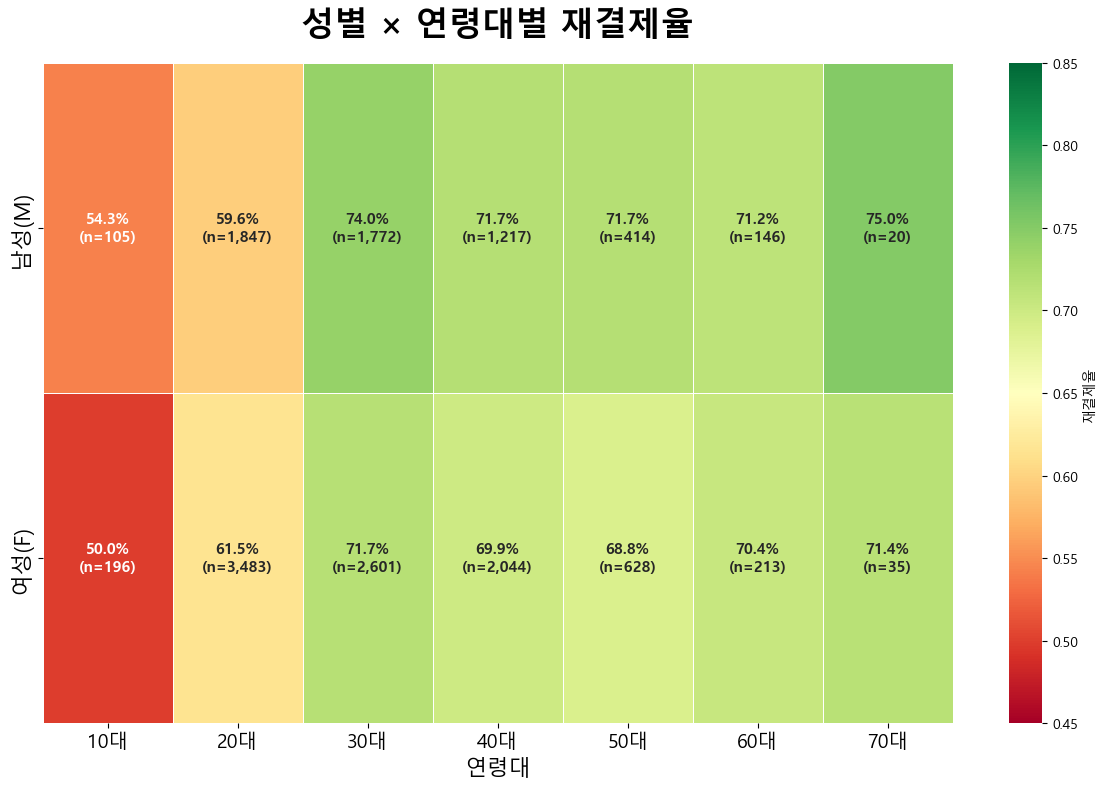

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# age 숫자형 변환
temp["age"] = pd.to_numeric(temp["age"], errors="coerce")

# gender가 F, M인 데이터만 사용
temp = temp[temp["gender"].isin(["F", "M"])].copy()

# age가 10 이상 80 미만인 데이터만 사용
temp = temp[(temp["age"] >= 10) & (temp["age"] < 80)].copy()

# repurchase가 O이면 1, 비어있으면 0으로 변환
temp["repurchase_flag"] = (
    temp["repurchase"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("O")
    .astype(int)
)

# age를 10단위 연령대로 재구성
temp["age_band_num"] = (temp["age"] // 10 * 10).astype(int)
temp["age_band"] = temp["age_band_num"].astype(str) + "대"

# 10대 ~ 70대 순서 지정
age_order = [f"{i}대" for i in range(10, 80, 10)]
temp["age_band"] = pd.Categorical(temp["age_band"], categories=age_order, ordered=True)

# 성별 라벨 생성
gender_map = {
    "F": "여성(F)",
    "M": "남성(M)"
}
gender_order = ["여성(F)", "남성(M)"]
temp["gender_label"] = temp["gender"].map(gender_map)
temp["gender_label"] = pd.Categorical(temp["gender_label"], categories=gender_order, ordered=True)

# 성별 × 연령대별 집계
summary = (
    temp.groupby(["gender_label", "age_band"], observed=False)
    .agg(
        count=("repurchase_flag", "size"),
        repurchase_count=("repurchase_flag", "sum"),
        repurchase_rate=("repurchase_flag", "mean")
    )
    .reset_index()
)

# 모든 조합 생성
full_index = pd.MultiIndex.from_product(
    [gender_order, age_order],
    names=["gender_label", "age_band"]
)

summary = (
    summary.set_index(["gender_label", "age_band"])
    .reindex(full_index)
    .reset_index()
)

# count 결측값 보정
summary["count"] = summary["count"].fillna(0).astype(int)
summary["repurchase_count"] = summary["repurchase_count"].fillna(0).astype(int)

# 피벗 테이블 생성
rate_pivot = summary.pivot(index="gender_label", columns="age_band", values="repurchase_rate")
count_pivot = summary.pivot(index="gender_label", columns="age_band", values="count")

# 셀 안 annotation 생성
annot = rate_pivot.copy().astype(object)

for row in rate_pivot.index:
    for col in rate_pivot.columns:
        rate = rate_pivot.loc[row, col]
        cnt = count_pivot.loc[row, col]

        if pd.isna(rate) or cnt == 0:
            annot.loc[row, col] = ""
        else:
            annot.loc[row, col] = f"{rate * 100:.1f}%\n(n={cnt:,})"

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 히트맵 생성
plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    rate_pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    vmin=0.45,
    vmax=0.85,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "재결제율"},
    annot_kws={"size": 11, "weight": "bold"}
)

# 제목 및 축 설정
ax.set_title("성별 × 연령대별 재결제율", fontsize=24, weight="bold", pad=20)
ax.set_xlabel("연령대", fontsize=16)
ax.set_ylabel("", fontsize=16)

# 축 글자 크기 설정
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=16)

plt.tight_layout()
plt.show()


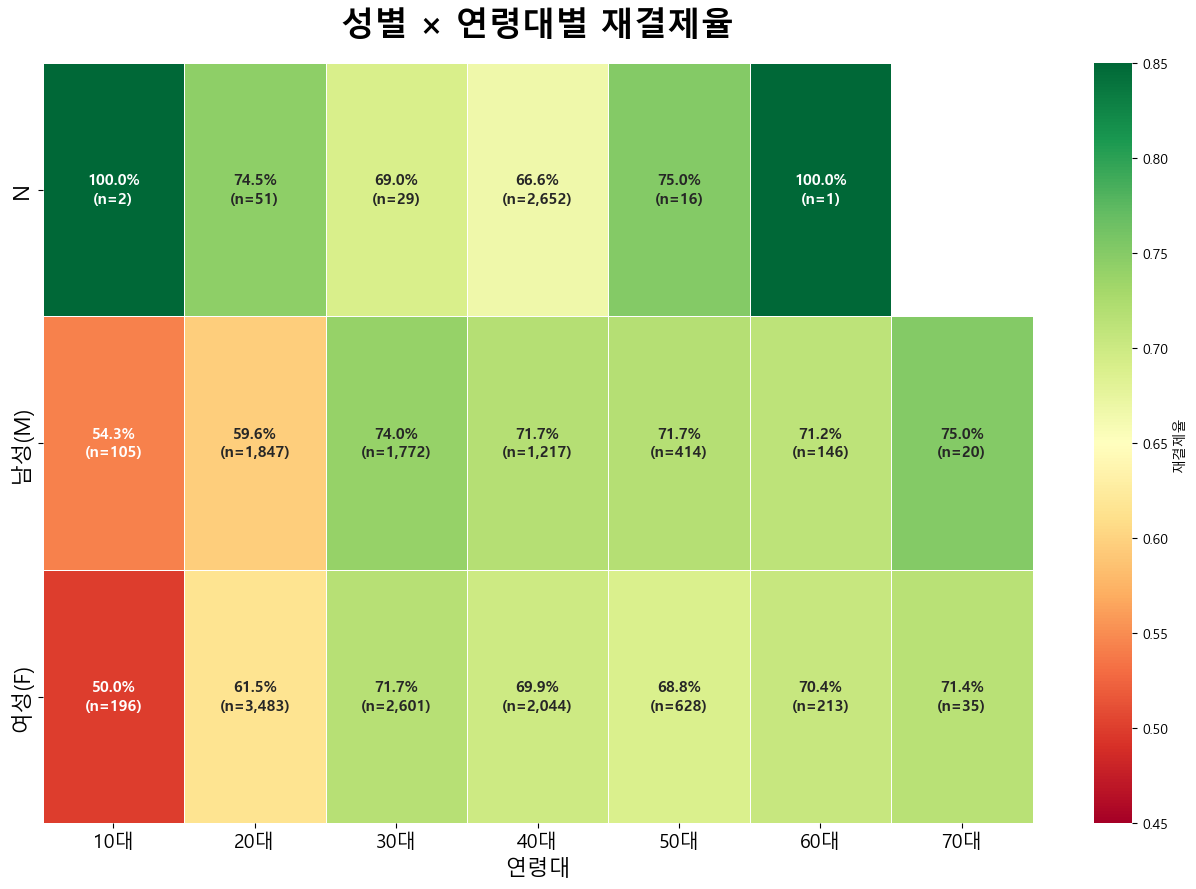

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# age 숫자형 변환
temp["age"] = pd.to_numeric(temp["age"], errors="coerce")

# gender가 F, M, N인 데이터만 사용
temp = temp[temp["gender"].isin(["F", "M", "N"])].copy()

# age가 10 이상 80 미만인 데이터만 사용
temp = temp[(temp["age"] >= 10) & (temp["age"] < 80)].copy()

# repurchase 이진 변수 생성
temp["repurchase_flag"] = (
    temp["repurchase"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("O")
    .astype(int)
)

# age 10단위 연령대 생성
temp["age_band_num"] = (temp["age"] // 10 * 10).astype(int)
temp["age_band"] = temp["age_band_num"].astype(str) + "대"

# 연령대 순서 지정
age_order = [f"{i}대" for i in range(10, 80, 10)]
temp["age_band"] = pd.Categorical(temp["age_band"], categories=age_order, ordered=True)

# 성별 라벨 생성
gender_map = {
    "F": "여성(F)",
    "M": "남성(M)",
    "N": "N"
}
gender_order = ["여성(F)", "남성(M)", "N"]

temp["gender_label"] = temp["gender"].map(gender_map)
temp["gender_label"] = pd.Categorical(temp["gender_label"], categories=gender_order, ordered=True)

# 성별 × 연령대별 집계
summary = (
    temp.groupby(["gender_label", "age_band"], observed=False)
    .agg(
        count=("repurchase_flag", "size"),
        repurchase_count=("repurchase_flag", "sum"),
        repurchase_rate=("repurchase_flag", "mean")
    )
    .reset_index()
)

# 모든 성별 × 연령대 조합 생성
full_index = pd.MultiIndex.from_product(
    [gender_order, age_order],
    names=["gender_label", "age_band"]
)

summary = (
    summary.set_index(["gender_label", "age_band"])
    .reindex(full_index)
    .reset_index()
)

# 결측값 보정
summary["count"] = summary["count"].fillna(0).astype(int)
summary["repurchase_count"] = summary["repurchase_count"].fillna(0).astype(int)

# 피벗 테이블 생성
rate_pivot = summary.pivot(index="gender_label", columns="age_band", values="repurchase_rate")
count_pivot = summary.pivot(index="gender_label", columns="age_band", values="count")

# 셀 표시용 annotation 생성
annot = rate_pivot.copy().astype(object)

for row in rate_pivot.index:
    for col in rate_pivot.columns:
        rate = rate_pivot.loc[row, col]
        cnt = count_pivot.loc[row, col]

        if pd.isna(rate) or cnt == 0:
            annot.loc[row, col] = ""
        else:
            annot.loc[row, col] = f"{rate * 100:.1f}%\n(n={cnt:,})"

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 히트맵 생성
plt.figure(figsize=(13, 9))

ax = sns.heatmap(
    rate_pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    vmin=0.45,
    vmax=0.85,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "재결제율"},
    annot_kws={"size": 11, "weight": "bold"}
)

# 제목 및 축 설정
ax.set_title("성별 × 연령대별 재결제율", fontsize=24, weight="bold", pad=20)
ax.set_xlabel("연령대", fontsize=16)
ax.set_ylabel("", fontsize=16)

# 축 글자 크기 설정
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=16)

plt.tight_layout()
plt.show()


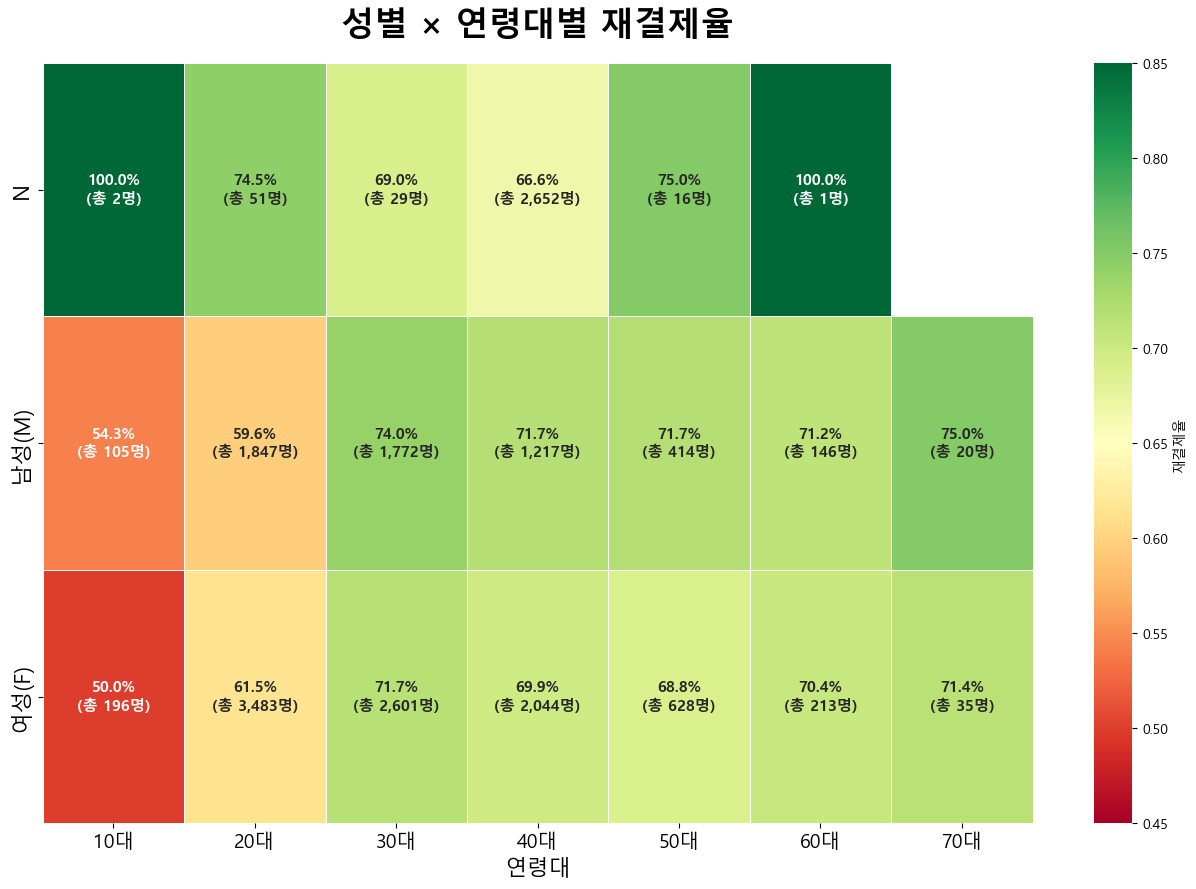

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# age 숫자형 변환
temp["age"] = pd.to_numeric(temp["age"], errors="coerce")

# 성별 유효값 필터링
temp = temp[temp["gender"].isin(["F", "M", "N"])].copy()

# 연령 유효 범위 필터링
temp = temp[(temp["age"] >= 10) & (temp["age"] < 80)].copy()

# repurchase 값 정규화
temp["repurchase_clean"] = (
    temp["repurchase"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)

# repurchase 유효값 필터링
temp = temp[temp["repurchase_clean"].isin(["", "O"])].copy()

# 재결제 여부 플래그 생성
temp["repurchase_flag"] = temp["repurchase_clean"].eq("O").astype(int)

# 10세 단위 연령대 생성
temp["age_band_num"] = (temp["age"] // 10 * 10).astype(int)
temp["age_band"] = temp["age_band_num"].astype(str) + "대"

# 연령대 순서 지정
age_order = [f"{i}대" for i in range(10, 80, 10)]
temp["age_band"] = pd.Categorical(
    temp["age_band"],
    categories=age_order,
    ordered=True
)

# 성별 라벨 생성
gender_map = {
    "F": "여성(F)",
    "M": "남성(M)",
    "N": "N"
}
gender_order = ["여성(F)", "남성(M)", "N"]

temp["gender_label"] = temp["gender"].map(gender_map)
temp["gender_label"] = pd.Categorical(
    temp["gender_label"],
    categories=gender_order,
    ordered=True
)

# 성별 × 연령대별 집계
summary = (
    temp.groupby(["gender_label", "age_band"], observed=False)
    .agg(
        count=("repurchase_flag", "size"),
        repurchase_count=("repurchase_flag", "sum")
    )
    .reset_index()
)

# 모든 성별 × 연령대 조합 생성
full_index = pd.MultiIndex.from_product(
    [gender_order, age_order],
    names=["gender_label", "age_band"]
)

summary = (
    summary.set_index(["gender_label", "age_band"])
    .reindex(full_index)
    .reset_index()
)

# 결측 조합 보정
summary["count"] = summary["count"].fillna(0).astype(int)
summary["repurchase_count"] = summary["repurchase_count"].fillna(0).astype(int)

# 재결제율 계산
summary["repurchase_rate"] = np.where(
    summary["count"] > 0,
    summary["repurchase_count"] / summary["count"],
    np.nan
)

# 피벗 테이블 생성
rate_pivot = summary.pivot(
    index="gender_label",
    columns="age_band",
    values="repurchase_rate"
)
count_pivot = summary.pivot(
    index="gender_label",
    columns="age_band",
    values="count"
)

# 셀 주석 생성
annot = rate_pivot.copy().astype(object)

for row in rate_pivot.index:
    for col in rate_pivot.columns:
        rate = rate_pivot.loc[row, col]
        count = count_pivot.loc[row, col]

        if pd.isna(rate) or count == 0:
            annot.loc[row, col] = ""
        else:
            annot.loc[row, col] = f"{rate * 100:.1f}%\n(총 {count:,}명)"

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 히트맵 생성
plt.figure(figsize=(13, 9))

ax = sns.heatmap(
    rate_pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    vmin=0.45,
    vmax=0.85,
    mask=rate_pivot.isna(),
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "재결제율"},
    annot_kws={"size": 11, "weight": "bold"}
)

# 제목 및 축 설정
ax.set_title("성별 × 연령대별 재결제율", fontsize=24, weight="bold", pad=20)
ax.set_xlabel("연령대", fontsize=16)
ax.set_ylabel("", fontsize=16)

# 축 글자 크기 설정
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=16)

# 레이아웃 정리
plt.tight_layout()
plt.show()


### 인증된 고객에 한해서
> 성별과 나이대에 따른 재결제율

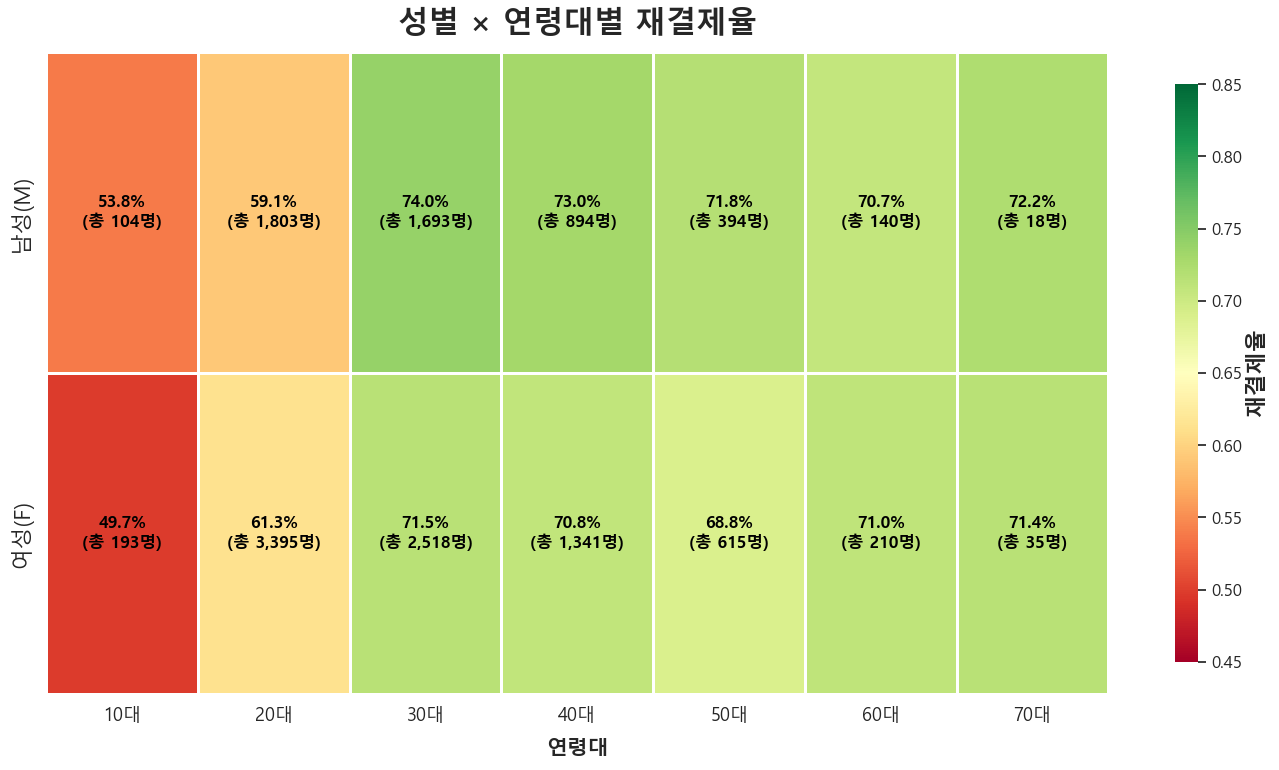

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 강제 적용
font_path = r"C:\Windows\Fonts\malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="white", font=font_name)

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# 본인 인증 완료 사용자 필터링
temp["is_user_verified"] = (
    temp["is_user_verified"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)
temp = temp[temp["is_user_verified"] == "Y"].copy()

# age 숫자형 변환
temp["age"] = pd.to_numeric(temp["age"], errors="coerce")

# 성별 유효값 필터링
temp = temp[temp["gender"].isin(["F", "M"])].copy()

# 연령 유효 범위 필터링
temp = temp[(temp["age"] >= 10) & (temp["age"] < 80)].copy()

# repurchase 값 정규화
temp["repurchase_clean"] = (
    temp["repurchase"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)

# repurchase 유효값 필터링
temp = temp[temp["repurchase_clean"].isin(["", "O"])].copy()

# 재결제 여부 플래그 생성
temp["repurchase_flag"] = temp["repurchase_clean"].eq("O").astype(int)

# 10세 단위 연령대 생성
temp["age_band_num"] = (temp["age"] // 10 * 10).astype(int)
temp["age_band"] = temp["age_band_num"].astype(str) + "대"

# 연령대 순서 지정
age_order = [f"{i}대" for i in range(10, 80, 10)]
temp["age_band"] = pd.Categorical(
    temp["age_band"],
    categories=age_order,
    ordered=True
)

# 성별 라벨 생성
gender_map = {
    "F": "여성(F)",
    "M": "남성(M)"
}
gender_order = ["여성(F)", "남성(M)"]

temp["gender_label"] = temp["gender"].map(gender_map)
temp["gender_label"] = pd.Categorical(
    temp["gender_label"],
    categories=gender_order,
    ordered=True
)

# 성별 × 연령대별 집계
summary = (
    temp.groupby(["gender_label", "age_band"], observed=False)
    .agg(
        count=("repurchase_flag", "size"),
        repurchase_count=("repurchase_flag", "sum")
    )
    .reset_index()
)

# 모든 성별 × 연령대 조합 생성
full_index = pd.MultiIndex.from_product(
    [gender_order, age_order],
    names=["gender_label", "age_band"]
)

summary = (
    summary.set_index(["gender_label", "age_band"])
    .reindex(full_index)
    .reset_index()
)

# 결측 조합 보정
summary["count"] = summary["count"].fillna(0).astype(int)
summary["repurchase_count"] = summary["repurchase_count"].fillna(0).astype(int)

# 재결제율 계산
summary["repurchase_rate"] = np.where(
    summary["count"] > 0,
    summary["repurchase_count"] / summary["count"],
    np.nan
)

# 피벗 테이블 생성
rate_pivot = summary.pivot(
    index="gender_label",
    columns="age_band",
    values="repurchase_rate"
)
count_pivot = summary.pivot(
    index="gender_label",
    columns="age_band",
    values="count"
)

# 셀 주석 생성
annot = rate_pivot.copy().astype(object)

for row in rate_pivot.index:
    for col in rate_pivot.columns:
        rate = rate_pivot.loc[row, col]
        count = count_pivot.loc[row, col]

        if pd.isna(rate) or count == 0:
            annot.loc[row, col] = ""
        else:
            annot.loc[row, col] = f"{rate * 100:.1f}%\n(총 {count:,}명)"

# 히트맵 생성
fig, ax = plt.subplots(figsize=(14, 8))

heatmap = sns.heatmap(
    rate_pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    vmin=0.45,
    vmax=0.85,
    mask=rate_pivot.isna(),
    linewidths=0.8,
    linecolor="white",
    cbar_kws={
        "label": "재결제율",
        "shrink": 0.9,
        "aspect": 25,
        "pad": 0.05
    },
    annot_kws={
        "size": 12,
        "weight": "bold",
        "color": "black"
    },
    ax=ax
)

# 컬러바 설정
cbar = heatmap.collections[0].colorbar
cbar.set_label("재결제율", fontsize=16, weight="bold")
cbar.ax.tick_params(labelsize=12)

# 축 설정
ax.set_xlabel("연령대", fontsize=15, weight="bold", labelpad=10)
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=16)

# 기본 제목 제거
ax.set_title("")

# 레이아웃 정리
plt.tight_layout(rect=[0, 0, 1, 0.93])

# 히트맵 기준 제목 위치 계산
bbox = ax.get_position()
title_x = (bbox.x0 + bbox.x1) / 2
title_y = bbox.y1 + 0.015

# 제목 직접 배치
fig.text(
    title_x,
    title_y,
    "성별 × 연령대별 재결제율",
    ha="center",
    va="bottom",
    fontsize=22,
    fontweight="bold"
)

plt.show()


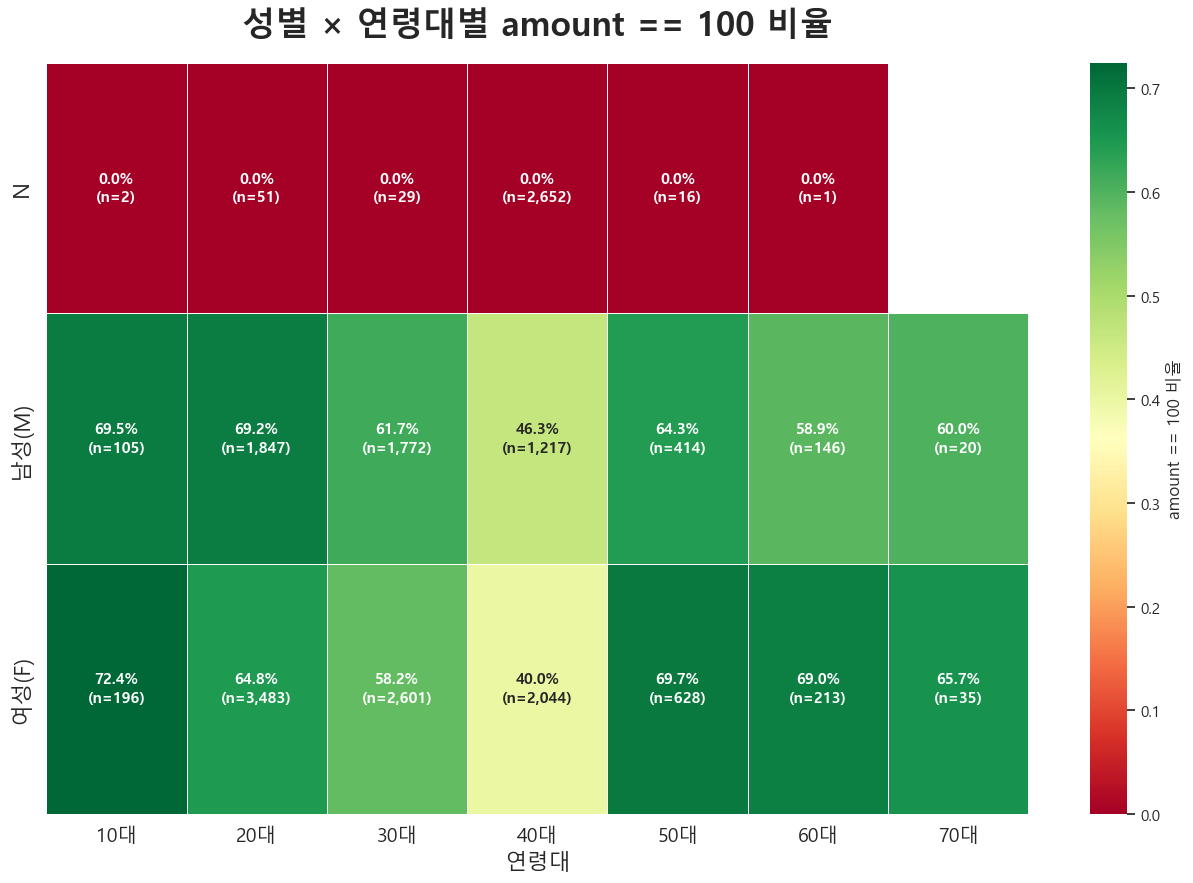

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# age, amount 숫자형 변환
temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
temp["amount"] = pd.to_numeric(temp["amount"], errors="coerce")

# gender가 F, M, N인 데이터만 사용
temp = temp[temp["gender"].isin(["F", "M", "N"])].copy()

# age가 10 이상 80 미만인 데이터만 사용
temp = temp[(temp["age"] >= 10) & (temp["age"] < 80)].copy()

# amount == 100 여부 이진 변수 생성
temp["amount_100_flag"] = temp["amount"].eq(100).astype(int)

# age 10단위 연령대 생성
temp["age_band_num"] = (temp["age"] // 10 * 10).astype(int)
temp["age_band"] = temp["age_band_num"].astype(str) + "대"

# 연령대 순서 지정
age_order = [f"{i}대" for i in range(10, 80, 10)]
temp["age_band"] = pd.Categorical(temp["age_band"], categories=age_order, ordered=True)

# 성별 라벨 생성
gender_map = {
    "F": "여성(F)",
    "M": "남성(M)",
    "N": "N"
}
gender_order = ["여성(F)", "남성(M)", "N"]

temp["gender_label"] = temp["gender"].map(gender_map)
temp["gender_label"] = pd.Categorical(temp["gender_label"], categories=gender_order, ordered=True)

# 성별 × 연령대별 집계
summary = (
    temp.groupby(["gender_label", "age_band"], observed=False)
    .agg(
        count=("amount_100_flag", "size"),
        amount_100_count=("amount_100_flag", "sum"),
        amount_100_rate=("amount_100_flag", "mean")
    )
    .reset_index()
)

# 모든 성별 × 연령대 조합 생성
full_index = pd.MultiIndex.from_product(
    [gender_order, age_order],
    names=["gender_label", "age_band"]
)

summary = (
    summary.set_index(["gender_label", "age_band"])
    .reindex(full_index)
    .reset_index()
)

# 결측값 보정
summary["count"] = summary["count"].fillna(0).astype(int)
summary["amount_100_count"] = summary["amount_100_count"].fillna(0).astype(int)

# 피벗 테이블 생성
rate_pivot = summary.pivot(index="gender_label", columns="age_band", values="amount_100_rate")
count_pivot = summary.pivot(index="gender_label", columns="age_band", values="count")

# 셀 표시용 annotation 생성
annot = rate_pivot.copy().astype(object)

for row in rate_pivot.index:
    for col in rate_pivot.columns:
        rate = rate_pivot.loc[row, col]
        cnt = count_pivot.loc[row, col]

        if pd.isna(rate) or cnt == 0:
            annot.loc[row, col] = ""
        else:
            annot.loc[row, col] = f"{rate * 100:.1f}%\n(n={cnt:,})"

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 히트맵 생성
plt.figure(figsize=(13, 9))

ax = sns.heatmap(
    rate_pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "amount == 100 비율"},
    annot_kws={"size": 11, "weight": "bold"}
)

# 제목 및 축 설정
ax.set_title("성별 × 연령대별 amount == 100 비율", fontsize=24, weight="bold", pad=20)
ax.set_xlabel("연령대", fontsize=16)
ax.set_ylabel("", fontsize=16)

# 축 글자 크기 설정
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=16)

plt.tight_layout()
plt.show()

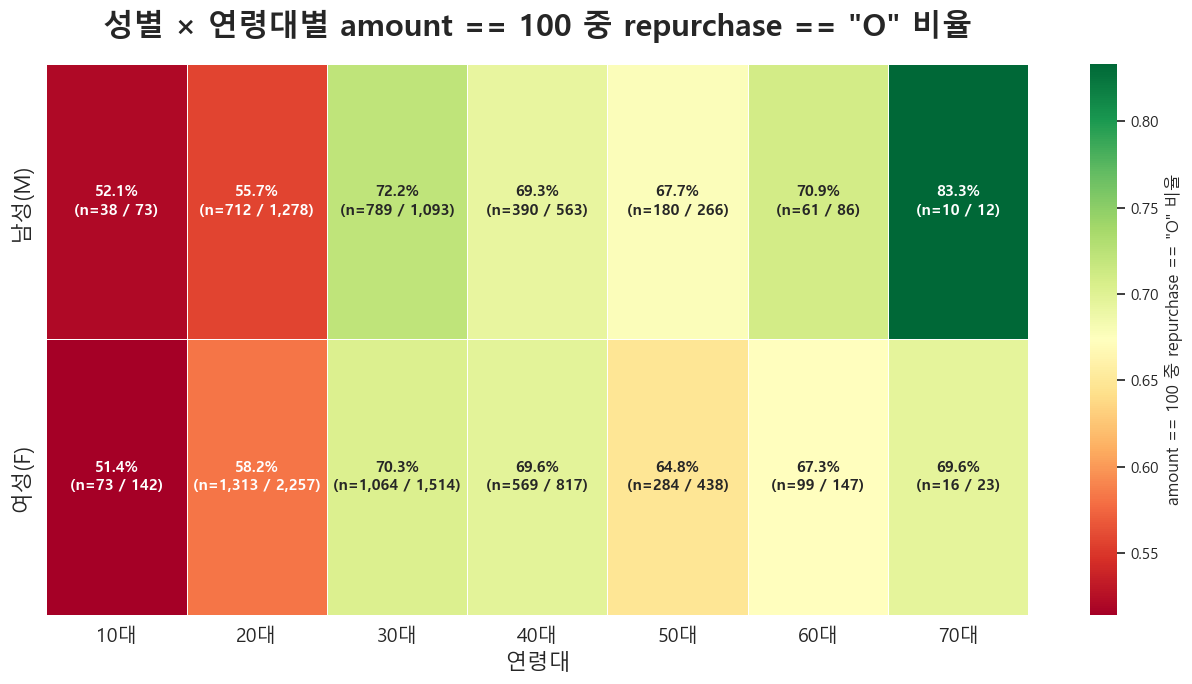

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# 수치형 변환
temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
temp["amount"] = pd.to_numeric(temp["amount"], errors="coerce")

# 문자열 정리
temp["gender"] = temp["gender"].astype(str).str.strip()
temp["repurchase"] = temp["repurchase"].fillna("").astype(str).str.strip()

# 성별 필터링
temp = temp[temp["gender"].isin(["F", "M"])].copy()

# 연령대 필터링
temp = temp[(temp["age"] >= 10) & (temp["age"] < 80)].copy()

# amount == 100 조건 필터링
temp = temp[temp["amount"] == 100].copy()

# repurchase == "O" 플래그 생성
temp["repurchase_o_flag"] = (temp["repurchase"] == "O").astype(int)

# 10단위 연령대 생성
temp["age_band_num"] = (temp["age"] // 10 * 10).astype(int)
temp["age_band"] = temp["age_band_num"].astype(str) + "대"

# 연령대 순서 지정
age_order = [f"{i}대" for i in range(10, 80, 10)]
temp["age_band"] = pd.Categorical(temp["age_band"], categories=age_order, ordered=True)

# 성별 라벨 생성
gender_map = {
    "F": "여성(F)",
    "M": "남성(M)"
}
gender_order = ["여성(F)", "남성(M)"]

temp["gender_label"] = temp["gender"].map(gender_map)
temp["gender_label"] = pd.Categorical(
    temp["gender_label"],
    categories=gender_order,
    ordered=True
)

# 성별 × 연령대별 집계
summary = (
    temp.groupby(["gender_label", "age_band"], observed=False)
    .agg(
        total_count=("repurchase_o_flag", "size"),
        target_count=("repurchase_o_flag", "sum"),
        target_rate=("repurchase_o_flag", "mean")
    )
    .reset_index()
)

# 전체 조합 생성
full_index = pd.MultiIndex.from_product(
    [gender_order, age_order],
    names=["gender_label", "age_band"]
)

summary = (
    summary.set_index(["gender_label", "age_band"])
    .reindex(full_index)
    .reset_index()
)

# 결측값 보정
summary["total_count"] = summary["total_count"].fillna(0).astype(int)
summary["target_count"] = summary["target_count"].fillna(0).astype(int)

# 피벗 테이블 생성
rate_pivot = summary.pivot(index="gender_label", columns="age_band", values="target_rate")
total_count_pivot = summary.pivot(index="gender_label", columns="age_band", values="total_count")
target_count_pivot = summary.pivot(index="gender_label", columns="age_band", values="target_count")

# 셀 표시 문자열 생성
annot = rate_pivot.copy().astype(object)

for row in rate_pivot.index:
    for col in rate_pivot.columns:
        rate = rate_pivot.loc[row, col]
        total_cnt = total_count_pivot.loc[row, col]
        target_cnt = target_count_pivot.loc[row, col]

        if pd.isna(rate) or total_cnt == 0:
            annot.loc[row, col] = ""
        else:
            annot.loc[row, col] = f"{rate * 100:.1f}%\n(n={int(target_cnt):,} / {int(total_cnt):,})"

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 히트맵 생성
plt.figure(figsize=(13, 7))

ax = sns.heatmap(
    rate_pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": 'amount == 100 중 repurchase == "O" 비율'},
    annot_kws={"size": 11, "weight": "bold"}
)

# 제목 및 축 설정
ax.set_title('성별 × 연령대별 amount == 100 중 repurchase == "O" 비율', fontsize=22, weight="bold", pad=20)
ax.set_xlabel("연령대", fontsize=16)
ax.set_ylabel("", fontsize=16)

# 축 글자 크기 설정
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=16)

plt.tight_layout()
plt.show()


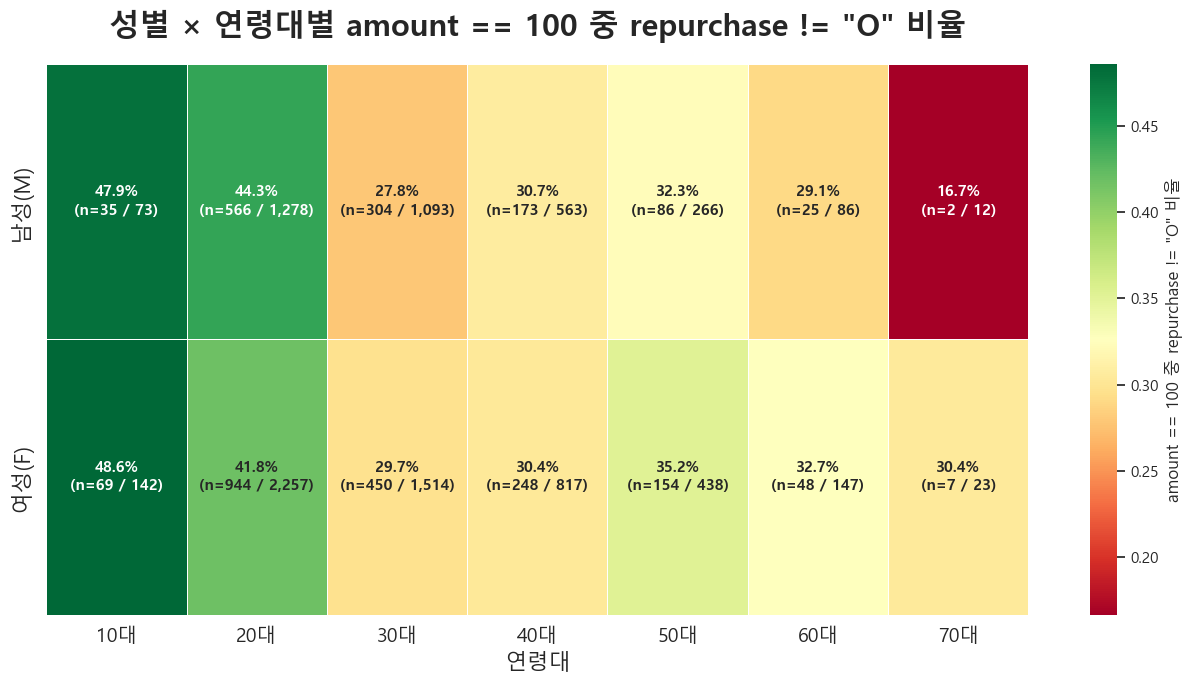

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# 수치형 변환
temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
temp["amount"] = pd.to_numeric(temp["amount"], errors="coerce")

# 문자열 정리
temp["gender"] = temp["gender"].astype(str).str.strip()
temp["repurchase"] = temp["repurchase"].fillna("").astype(str).str.strip()

# 성별 필터링
temp = temp[temp["gender"].isin(["F", "M"])].copy()

# 연령대 필터링
temp = temp[(temp["age"] >= 10) & (temp["age"] < 80)].copy()

# amount == 100 조건 필터링
temp = temp[temp["amount"] == 100].copy()

# repurchase != "O" 플래그 생성
temp["repurchase_not_o_flag"] = (temp["repurchase"] != "O").astype(int)

# 10단위 연령대 생성
temp["age_band_num"] = (temp["age"] // 10 * 10).astype(int)
temp["age_band"] = temp["age_band_num"].astype(str) + "대"

# 연령대 순서 지정
age_order = [f"{i}대" for i in range(10, 80, 10)]
temp["age_band"] = pd.Categorical(temp["age_band"], categories=age_order, ordered=True)

# 성별 라벨 생성
gender_map = {
    "F": "여성(F)",
    "M": "남성(M)"
}
gender_order = ["여성(F)", "남성(M)"]

temp["gender_label"] = temp["gender"].map(gender_map)
temp["gender_label"] = pd.Categorical(
    temp["gender_label"],
    categories=gender_order,
    ordered=True
)

# 성별 × 연령대별 집계
summary = (
    temp.groupby(["gender_label", "age_band"], observed=False)
    .agg(
        total_count=("repurchase_not_o_flag", "size"),
        target_count=("repurchase_not_o_flag", "sum"),
        target_rate=("repurchase_not_o_flag", "mean")
    )
    .reset_index()
)

# 전체 조합 생성
full_index = pd.MultiIndex.from_product(
    [gender_order, age_order],
    names=["gender_label", "age_band"]
)

summary = (
    summary.set_index(["gender_label", "age_band"])
    .reindex(full_index)
    .reset_index()
)

# 결측값 보정
summary["total_count"] = summary["total_count"].fillna(0).astype(int)
summary["target_count"] = summary["target_count"].fillna(0).astype(int)

# 피벗 테이블 생성
rate_pivot = summary.pivot(index="gender_label", columns="age_band", values="target_rate")
total_count_pivot = summary.pivot(index="gender_label", columns="age_band", values="total_count")
target_count_pivot = summary.pivot(index="gender_label", columns="age_band", values="target_count")

# 셀 표시 문자열 생성
annot = rate_pivot.copy().astype(object)

for row in rate_pivot.index:
    for col in rate_pivot.columns:
        rate = rate_pivot.loc[row, col]
        total_cnt = total_count_pivot.loc[row, col]
        target_cnt = target_count_pivot.loc[row, col]

        if pd.isna(rate) or total_cnt == 0:
            annot.loc[row, col] = ""
        else:
            annot.loc[row, col] = f"{rate * 100:.1f}%\n(n={int(target_cnt):,} / {int(total_cnt):,})"

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 히트맵 생성
plt.figure(figsize=(13, 7))

ax = sns.heatmap(
    rate_pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": 'amount == 100 중 repurchase != "O" 비율'},
    annot_kws={"size": 11, "weight": "bold"}
)

# 제목 및 축 설정
ax.set_title('성별 × 연령대별 amount == 100 중 repurchase != "O" 비율', fontsize=22, weight="bold", pad=20)
ax.set_xlabel("연령대", fontsize=16)
ax.set_ylabel("", fontsize=16)

# 축 글자 크기 설정
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=16)

plt.tight_layout()
plt.show()


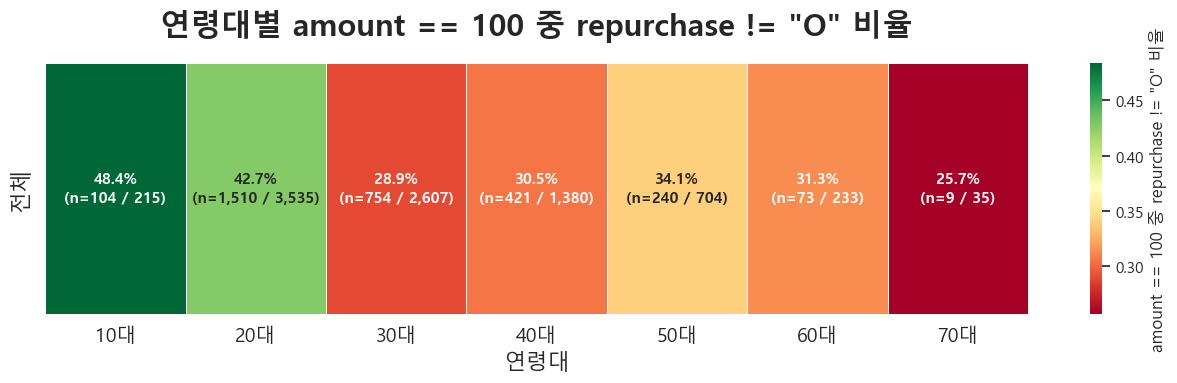

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 분석용 복사본 생성
temp = df_reg_end_cleaned.copy()

# 수치형 변환
temp["age"] = pd.to_numeric(temp["age"], errors="coerce")
temp["amount"] = pd.to_numeric(temp["amount"], errors="coerce")

# 문자열 정리
temp["gender"] = temp["gender"].astype(str).str.strip()
temp["repurchase"] = temp["repurchase"].fillna("").astype(str).str.strip()

# 성별 필터링
temp = temp[temp["gender"].isin(["F", "M"])].copy()

# 연령대 필터링
temp = temp[(temp["age"] >= 10) & (temp["age"] < 80)].copy()

# amount == 100 조건 필터링
temp = temp[temp["amount"] == 100].copy()

# repurchase != "O" 플래그 생성
temp["repurchase_not_o_flag"] = (temp["repurchase"] != "O").astype(int)

# 10단위 연령대 생성
temp["age_band_num"] = (temp["age"] // 10 * 10).astype(int)
temp["age_band"] = temp["age_band_num"].astype(str) + "대"

# 연령대 순서 지정
age_order = [f"{i}대" for i in range(10, 80, 10)]
temp["age_band"] = pd.Categorical(temp["age_band"], categories=age_order, ordered=True)

# 연령대별 집계
summary = (
    temp.groupby("age_band", observed=False)
    .agg(
        total_count=("repurchase_not_o_flag", "size"),
        target_count=("repurchase_not_o_flag", "sum"),
        target_rate=("repurchase_not_o_flag", "mean")
    )
    .reset_index()
)

# 전체 연령대 보정
summary = (
    summary.set_index("age_band")
    .reindex(age_order)
    .reset_index()
)

# 결측값 보정
summary["total_count"] = summary["total_count"].fillna(0).astype(int)
summary["target_count"] = summary["target_count"].fillna(0).astype(int)

# 히트맵용 단일 행 라벨 생성
summary["group_label"] = "전체"

# 피벗 테이블 생성
rate_pivot = summary.pivot(index="group_label", columns="age_band", values="target_rate")
total_count_pivot = summary.pivot(index="group_label", columns="age_band", values="total_count")
target_count_pivot = summary.pivot(index="group_label", columns="age_band", values="target_count")

# 셀 표시 문자열 생성
annot = rate_pivot.copy().astype(object)

for row in rate_pivot.index:
    for col in rate_pivot.columns:
        rate = rate_pivot.loc[row, col]
        total_cnt = total_count_pivot.loc[row, col]
        target_cnt = target_count_pivot.loc[row, col]

        if pd.isna(rate) or total_cnt == 0:
            annot.loc[row, col] = ""
        else:
            annot.loc[row, col] = f"{rate * 100:.1f}%\n(n={int(target_cnt):,} / {int(total_cnt):,})"

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 히트맵 생성
plt.figure(figsize=(13, 4))

ax = sns.heatmap(
    rate_pivot,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": 'amount == 100 중 repurchase != "O" 비율'},
    annot_kws={"size": 11, "weight": "bold"}
)

# 제목 및 축 설정
ax.set_title('연령대별 amount == 100 중 repurchase != "O" 비율', fontsize=22, weight="bold", pad=20)
ax.set_xlabel("연령대", fontsize=16)
ax.set_ylabel("", fontsize=16)

# 축 글자 크기 설정
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=16)

plt.tight_layout()
plt.show()
